<a href="https://colab.research.google.com/github/srijeeta-saha/data_dashboard/blob/main/p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)
n=500

data=[]

for _ in range(n):
  skin=np.random.choice(['Oily','Dry','Combination','Normal','Sensitive'],p=[0.25,0.20,0.25,0.20,0.10]) #without p  each skin type gets an equal 20% chance — NumPy picks uniformly by default.

  if skin == 'Oily':

          pores      = np.random.randint(3, 6)
          shine      = np.random.randint(3, 6)
          tightness  = np.random.randint(1, 3)
          sensitivity= np.random.randint(1, 3)
          flakiness  = np.random.randint(1, 3)
          breakouts  = np.random.randint(3, 6)
# randint returns a random integer from low to high - 1 where the upper limit is exclusive (not included)
  elif skin == 'Dry':
          pores      = np.random.randint(1, 3)
          shine      = np.random.randint(1,3)
          tightness  = np.random.randint(1,3)
          sensitivity= np.random.randint(2,5)
          flakiness  = np.random.randint(3,6)
          breakouts  = np.random.randint(1,3)

  elif skin == 'Combination':
        pores      = np.random.randint(2,5)
        shine      = np.random.randint(2,5)
        tightness  = np.random.randint(2,4)
        sensitivity= np.random.randint(1,4)
        flakiness  = np.random.randint(1,4)
        breakouts  = np.random.randint(2,5)
  elif skin == 'Normal':
        pores      = np.random.randint(1,4)
        shine      = np.random.randint(1,3)
        tightness  = np.random.randint(1,3)
        sensitivity= np.random.randint(1,3)
        flakiness  = np.random.randint(1,3)
        breakouts  = np.random.randint(1,3)
  else:
        pores      = np.random.randint(1, 4)
        shine      = np.random.randint(1, 4)
        tightness  = np.random.randint(2, 5)
        sensitivity= np.random.randint(4, 6)
        flakiness  = np.random.randint(2, 5)
        breakouts  = np.random.randint(2, 5)

  data.append([pores,shine,tightness,sensitivity,flakiness,breakouts,skin])

df =pd.DataFrame(data ,columns=['pores','shine','tightness','sensitivity','flakiness','breakouts','skin_type'])

df.to_csv('skin_data.csv',index=False)
print(df.head(10))
print("\nClass distribution:\n",df['skin_type'].value_counts())



   pores  shine  tightness  sensitivity  flakiness  breakouts    skin_type
0      1      1          1            2          3          1          Dry
1      1      1          1            2          5          2          Dry
2      4      4          2            2          2          3         Oily
3      3      3          2            1          1          4  Combination
4      3      4          3            2          3          3  Combination
5      5      3          1            1          1          5         Oily
6      5      4          2            1          2          4         Oily
7      1      2          1            2          2          2       Normal
8      1      2          1            4          5          2          Dry
9      2      2          2            3          4          2          Dry

Class distribution:
 skin_type
Oily           129
Combination    129
Normal         104
Dry            100
Sensitive       38
Name: count, dtype: int64


#Preprocessing + Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

#separate features and target
X=df.drop('skin_type',axis=1)  # inputs (6 quiz questions)
y=df['skin_type'] #output skin type

# Encode text labels → numbers
le=LabelEncoder()
y_encoded = le.fit_transform(y)

X_train ,X_test,y_train,y_test=train_test_split( X, y_encoded, test_size=0.2,random_state=42, stratify=y_encoded)

print("Total samples  :",len(df))
print("Trainig samples :",len(X_train))
print("Testing samples :",len(X_test))
print("\nLabel mapping:")
for i, name in enumerate(le.classes_):
  print(f" {i} -> {name}")



Total samples  : 500
Trainig samples : 400
Testing samples : 100

Label mapping:
 0 -> Combination
 1 -> Dry
 2 -> Normal
 3 -> Oily
 4 -> Sensitive


#trainig the model

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

#define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf',random_state=42)
}

#train and evaluate each model
results ={}

for name,model in models.items():

  #train
  model.fit(X_train,y_train)

  #predict on test set
  y_pred = model.predict(X_test)

  #Accuracy

acc=accuracy_score(y_test,y_pred)
results[name]=acc

print(f"\n{'='*40}")
print(f"{name }")
print(f"\n{'='*40}")
print(f"Accuracy: {acc*100:.2f}%")
print(f"\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

      #summary
print("\nModel Comparison:")
for name,acc in  results.items():
  print(f"{name:20s} -> {acc*100:2f}%")


SVM

Accuracy: 96.00%

 Classification Report:
              precision    recall  f1-score   support

 Combination       0.96      0.88      0.92        26
         Dry       1.00      1.00      1.00        20
      Normal       1.00      1.00      1.00        21
        Oily       0.89      0.96      0.93        26
   Sensitive       1.00      1.00      1.00         7

    accuracy                           0.96       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.96      0.96      0.96       100


Model Comparison:
SVM                  -> 96.000000%


In [8]:
print("Model Comparison:")
for name,acc in  results.items():
  print(f"{name:20s} -> {acc*100:2f}%")

Model Comparison:
SVM                  -> 96.000000%


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'          : KNeighborsClassifier(n_neighbors=5),
    'SVM'          : SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} → {acc*100:.2f}%")

print("\nDone! All 3 models trained.")

Random Forest → 96.00%
KNN → 96.00%
SVM → 96.00%

Done! All 3 models trained.


Feature Importance (which questions matters most):
 flakiness       -> 19.344485
 breakouts       -> 18.701846
 shine           -> 18.098600
 tightness       -> 16.764370
 sensitivity     -> 15.975828
 pores           -> 11.114871


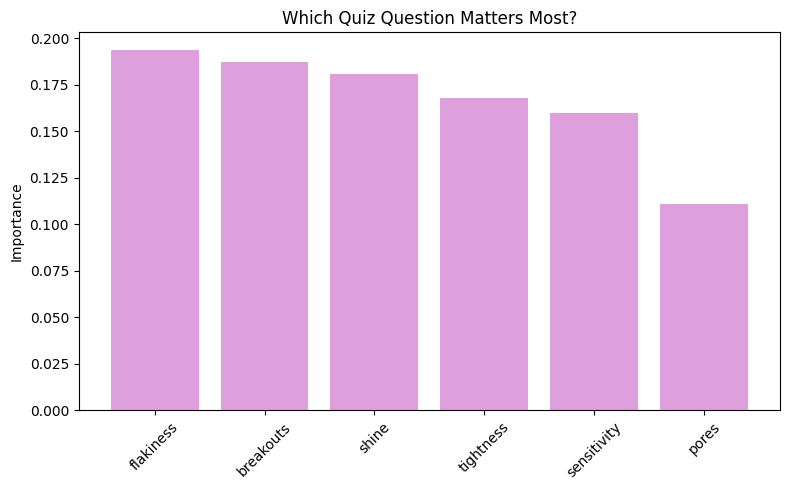


Model saved as skin_model.pkl


In [10]:
import joblib
import matplotlib.pyplot as plt
import numpy as np

final_model = models['Random Forest']

features = ['pores','shine','tightness','sensitivity','flakiness','breakouts']
importance = final_model.feature_importances_

indices = np.argsort(importance)[::-1]

print("Feature Importance (which questions matters most):")
for i in indices:
  print(f" {features[i]:15s} -> {importance[i]*100:2f}")

plt.figure(figsize=(8,5))
plt.bar(range(len(features)),importance[indices], color='plum')
plt.xticks(range(len(features)) , [features[i] for i in indices], rotation = 45)
plt.title('Which Quiz Question Matters Most?')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

joblib.dump(final_model, 'skin_model.pkl')
joblib.dump(le,'label_encoder.pkl')
print("\nModel saved as skin_model.pkl")

In [11]:
import joblib

# Load saved model and encoder
model = joblib.load('skin_model.pkl')
le    = joblib.load('label_encoder.pkl')

def ask_question(question):
    while True:
        try:
            ans = int(input(f"\n{question}\n(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): "))
            if 1 <= ans <= 5:
                return ans
            else:
                print("Please enter a number between 1 and 5.")
        except ValueError:
            print("Invalid input. Please enter a number.")

def skin_type_quiz():
    print("="*45)
    print("   ✨ SKIN TYPE QUIZ ✨")
    print("="*45)
    print("Answer 6 simple questions about your skin.")

    pores       = ask_question("Q1. How visible are your pores?")
    shine       = ask_question("Q2. How shiny is your face by afternoon?")
    tightness   = ask_question("Q3. How tight/dry does your skin feel?")
    sensitivity = ask_question("Q4. How often does skin react to new products?")
    flakiness   = ask_question("Q5. How much flakiness/dry patches do you get?")
    breakouts   = ask_question("Q6. How often do you break out?")

    # Predict
    user_input  = [[pores, shine, tightness, sensitivity, flakiness, breakouts]]
    prediction  = model.predict(user_input)
    skin_type   = le.inverse_transform(prediction)[0]

    # Result + advice
    advice = {
        'Oily'       : "Use a gentle foaming cleanser, niacinamide serum, and oil-free moisturizer.",
        'Dry'        : "Use a cream cleanser, hyaluronic acid serum, and a rich moisturizer.",
        'Combination': "Use a balanced cleanser, target oily T-zone with niacinamide, moisturize dry areas.",
        'Normal'     : "You have balanced skin! Maintain with a simple cleanser and light moisturizer.",
        'Sensitive'  : "Use fragrance-free, alcohol-free products. Centella or oat-based products work best."
    }

    print("\n" + "="*45)
    print(f"   Your Skin Type: {skin_type.upper()} 🌿")
    print("="*45)
    print(f"\n💡 Advice: {advice[skin_type]}")

# Run the quiz
skin_type_quiz()

   ✨ SKIN TYPE QUIZ ✨
Answer 6 simple questions about your skin.

Q1. How visible are your pores?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): low
Invalid input. Please enter a number.

Q1. How visible are your pores?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): 1

Q2. How shiny is your face by afternoon?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): 2

Q3. How tight/dry does your skin feel?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): 3

Q4. How often does skin react to new products?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): 3

Q5. How much flakiness/dry patches do you get?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): 1

Q6. How often do you break out?
(Enter 1=Very Low, 2=Low, 3=Medium, 4=High, 5=Very High): 3

   Your Skin Type: COMBINATION 🌿

💡 Advice: Use a balanced cleanser, target oily T-zone with niacinamide, moisturize dry areas.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
